In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# 1. Feature CSV 로드
df = pd.read_csv("../kafka_streams/feature_topic_samples/feature_tooldelay_s02.csv", parse_dates=["timestamp"])
df.head()

,timestamp,production_interval_avg,production_interval_std,cycle_time_avg,cycle_time_std,alarm_count,alarm_rate,hold_count,idle_count,manual_mode_count,good_count,reject_count,reject_rate,reject_streak
0,2026-03-03 08:14:50+00:00,160.0,0.0,150.0,0.0,1,0.2,0,0,0,5,0,0.0,0
1,2026-03-03 08:17:30+00:00,160.0,0.0,150.0,0.0,1,0.2,0,0,0,4,1,0.2,1
2,2026-03-03 08:20:10+00:00,160.0,0.0,150.0,0.0,1,0.2,0,0,0,4,1,0.2,1
3,2026-03-03 08:22:50+00:00,160.0,0.0,150.0,0.0,1,0.2,0,0,0,3,2,0.4,1
4,2026-03-03 08:25:30+00:00,160.0,0.0,150.0,0.0,1,0.2,0,0,0,2,3,0.6,2


In [5]:
# 규칙 기반 이상 감지
df['rule_alert'] = 0
# Reject streak 2 이상 → 경고
df.loc[df['reject_streak'] >= 2, 'rule_alert'] = 1
# 사이클 지연 > 10% → 경고
df.loc[df['cycle_time_avg'] > 150*1.1, 'rule_alert'] = 1


In [6]:
# 통계 기반 이상 감지
features = ['production_interval_avg','reject_count','alarm_count']
window = 5

for col in features:
    df[f'{col}_mean'] = df[col].shift(1).rolling(window).mean()
    df[f'{col}_std'] = df[col].shift(1).rolling(window).std().replace(0, 1e-6)
    df[f'{col}_zscore'] = np.abs(df[col] - df[f'{col}_mean']) / df[f'{col}_std']
    df[f'{col}_zscore'] = df[f'{col}_zscore'].fillna(0)

# threshold = 2
df['stat_alert'] = (df[[f'{col}_zscore' for col in features]] > 2).any(axis=1).astype(int)


# 통합 이상 알람
df['combined_alert'] = df[['rule_alert','stat_alert']].max(axis=1)

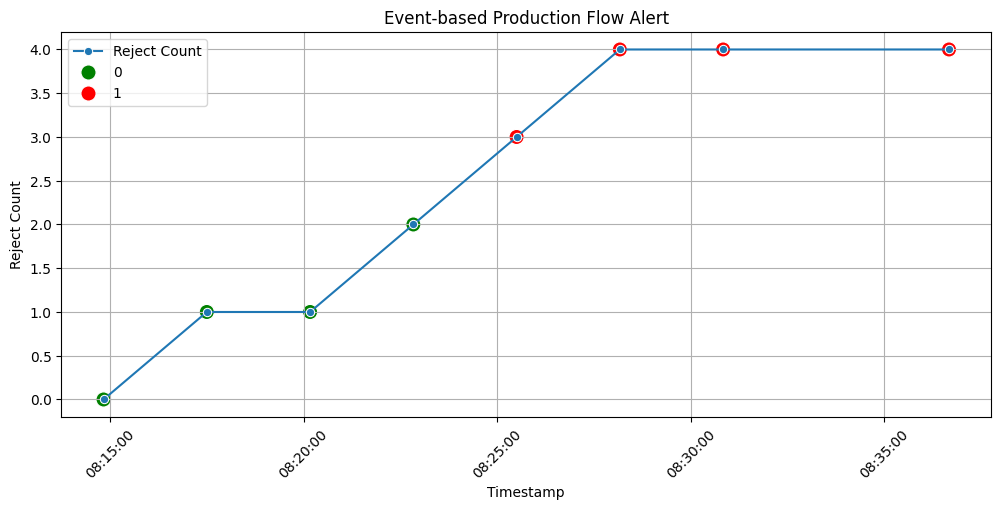

In [7]:
# 시각화
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='timestamp', y='reject_count', marker='o', label='Reject Count')
sns.scatterplot(data=df, x='timestamp', y='reject_count', hue='combined_alert',
                palette={0:'green',1:'red'}, s=120)

plt.title("Event-based Production Flow Alert")
plt.xlabel("Timestamp")
plt.ylabel("Reject Count")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.show()

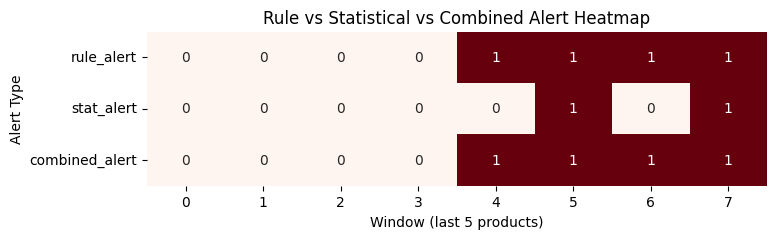

In [8]:
# 히트맵: Rule vs Statistical Alert 비교
alert_map = df[['rule_alert','stat_alert','combined_alert']].T
plt.figure(figsize=(8,2))
sns.heatmap(alert_map, annot=True, cmap='Reds', cbar=False)
plt.title("Rule vs Statistical vs Combined Alert Heatmap")
plt.xlabel("Window (last 5 products)") 
plt.ylabel("Alert Type")
plt.show()